In [2]:
from scipy.signal import butter, filtfilt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### We extract noise patterns via high-pass filtering to use later as observational noise.

### Downloaded via https://www.macrotrends.net


In [4]:
# Use the Python engine and let pandas infer the separator; skip malformed lines to avoid ParserError
n = pd.read_csv('../semi_synthetic_bases/real_ts/nvidia.csv', engine='python', sep=",", skiprows=12)
g = pd.read_csv('../semi_synthetic_bases/real_ts/gold.csv')
s = pd.read_csv('../semi_synthetic_bases/real_ts/sp_500.csv')

In [5]:
def extract_filtered_noise(data):


    # Filter parameters
    cutoff_freq = 10 # Cutoff frequency in Hz
    fs = 500  # Sampling rate in Hz
    order = 4  # Filter order

    # Design the high-pass filter (change btype to 'highpass')
    nyq = 0.5 * fs
    normal_cutoff = cutoff_freq / nyq
    b, a = butter(order, normal_cutoff, btype='highpass')  # <-- modify here


    # Apply the filter
    filtered_data = filtfilt(b, a, data)

    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    # Plot the original and filtered data
    ax[0].plot(data, label='Original Signal')
    ax[0].plot(filtered_data, label='Filtered Signal')

    ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('Amplitude')
    ax[0].set_title('Original Signal')
    ax[0].legend()

    ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('Amplitude')
    ax[0].set_title('Filtered Signal')
    ax[0].legend()

    _ = ax[1].hist(filtered_data, bins=100)

    plt.show()
    return filtered_data

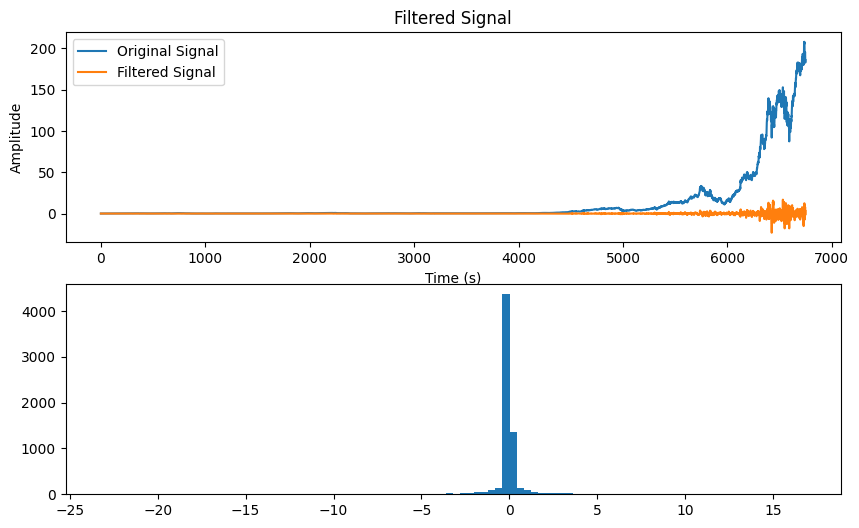

In [6]:
n_n = extract_filtered_noise(n["open"])
np.save('../semi_synthetic_bases/nvidia.npy', n_n)

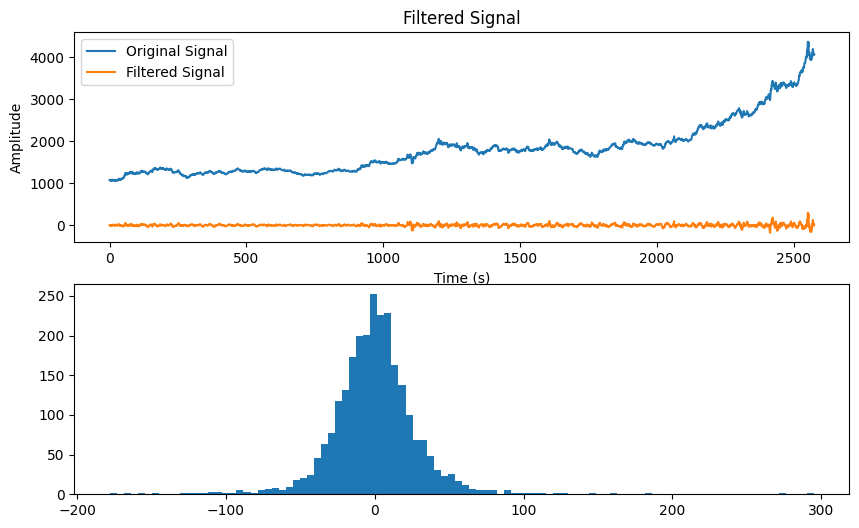

In [7]:
g_n = extract_filtered_noise(g["Value"])
np.save('../semi_synthetic_bases/gold.npy', g_n)

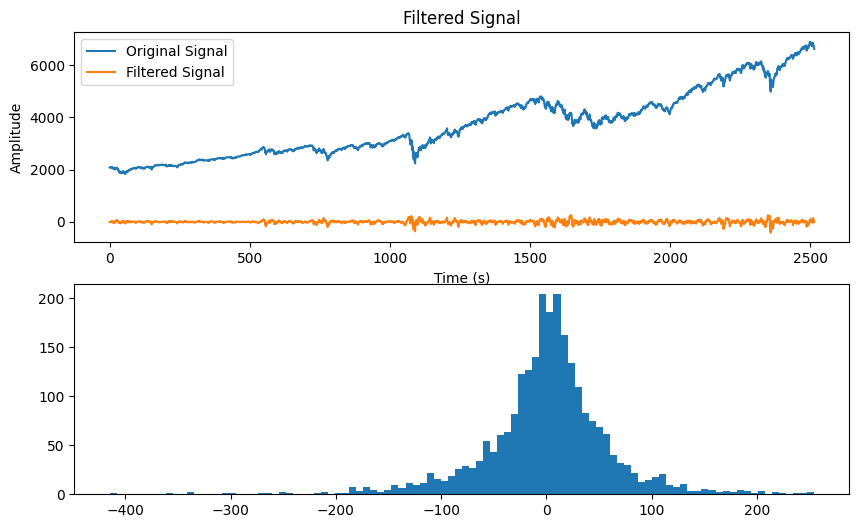

In [8]:
s_n = extract_filtered_noise(s["Value"])
np.save('../semi_synthetic_bases/s_p.npy', g_n)